In [1]:
import pandas as pd
import numpy as np
import sklearn as sk

In [2]:
import warnings
warnings.filterwarnings('ignore')


Para cumplir con esta tarea, necesitas un modelo que pueda manejar datos temporales:

1. Modelos basados en Series Temporales
Propósito: Capturar tendencias a lo largo del tiempo.

Modelos recomendados:

ARIMA (Autoregressive Integrated Moving Average):
Long Short-Term Memory (LSTM):

**ARIMA**

In [3]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
import glob

In [4]:
def cargar_simple(path="../Datasets/florida/restaurantes_*.csv"):
    # Cargar todos los archivos de datos
    archivos = glob.glob(path)
    datos = pd.concat([pd.read_csv(archivo) for archivo in archivos])
    return datos

In [5]:
datxs = cargar_simple()
datxs.head()

,id_nombre,nombre,direccion,id_ciudad,ciudad,codigo_postal,latitud,longitud,puntuacion_yelp,categories,puntuacion_usuarios,año,analisis_sentimientos
0,0cd7,Carmine's Restaurant and Bar,1802 E 7th Ave,20,Tampa,33664,27.960462,-82.439013,3.0,"Italian, Restaurants, Bars, Nightlife, Sandwic...",3.0,2005,0.5
1,1745,Island Way Grill,20 Island Way,42,Clearwater,33769,27.976278,-82.817396,3.5,"Seafood, Sushi Bars, Steakhouses, Restaurants",4.0,2005,1.0
2,4c35,Mise En Place,"442 W Kennedy Blvd, Ste 110",20,Tampa,33664,27.944680,-82.465137,4.0,"Event Planning & Services, Restaurants, Venues...",5.0,2005,1.0
3,6aa3,Bahama Breeze,3045 N Rocky Pt Dr E,20,Tampa,33664,27.969776,-82.562738,3.5,"Restaurants, Latin American, Laotian, Caribbea...",4.0,2005,1.0
4,7cd4,Bern's Steak House,1208 S Howard Ave,20,Tampa,33664,27.931862,-82.482700,4.5,"Arts & Entertainment, Steakhouses, Restaurants",5.0,2005,1.0


In [6]:

# Función para cargar y combinar datos
def cargar_datos(id_nombre, path="../Datasets/florida/restaurantes_*.csv"):
    # Cargar todos los archivos de datos
    archivos = glob.glob(path)
    datos = pd.concat([pd.read_csv(archivo) for archivo in archivos])
    
    # Filtrar por categoria del restaurante
    datos = datos[datos["id_nombre"] == id_nombre]
    
    # Ordenar por año
    datos = datos.sort_values(by='año')
    return datos[['año', 'puntuacion_usuarios']]


In [7]:
# Función para cargar y combinar datos de todos los restaurantes
def cargar_datos_generales(category, path="../Datasets/florida/restaurantes_*.csv"):
    # Cargar todos los archivos de datos
    archivos = glob.glob(path)
    datos = pd.concat([pd.read_csv(archivo) for archivo in archivos])
    
    datos = datos[datos['categories'].str.contains(category)]

    # Agrupar por año y calcular la puntuación promedio de todos los restaurantes
    datos_agrupados = datos.groupby('año')['puntuacion_usuarios'].mean().reset_index()
    return datos_agrupados

In [8]:
# Forecasting con ARIMA
def forecasting_arima(data, p=1, d=1, q=0):
    # Preparar datos
    series = data['puntuacion_usuarios']
    años = data['año']
    
    # Dividir en conjunto de entrenamiento y validación
    train, test = train_test_split(series, test_size=1, shuffle=False)
    
    # Ajustar el modelo ARIMA
    modelo = ARIMA(train, order=(p, d, q))
    modelo_fit = modelo.fit()
    # Generar predicción para el siguiente punto
    prediccion = list(modelo_fit.forecast(steps=1))[0]
    
    # Calcular el error si hay dato real en test
    if len(test) > 0:
        error = mean_absolute_error(test, [prediccion])
        # print(test)
        # print([prediccion])
        # print(f"MAE: {error:.2f}")
    
    # Mostrar resultados
    # print(f"Año: {años.iloc[-1] + 1}, Predicción: {prediccion}")
    return prediccion


In [39]:
# Forecasting con ARIMA para tendencias generales
def forecasting_tendencia_general(data, p=0, d=1, q=0):
    # Preparar datos
    series = data['puntuacion_usuarios']
    años = data['año']
    
    # Dividir en conjunto de entrenamiento y validación
    # train, test = train_test_split(series, test_size=0, shuffle=False)
    
    # print(f"Train data:\n{train}")
    # print(f"Type: {type(train)}, Length: {len(train)}")


    # Ensure train is a pandas Series
    train = pd.Series(series).reset_index(drop=True)
    
    # Ajustar el modelo ARIMA
    modelo = ARIMA(train, order=(p, d, q), enforce_stationarity=False, enforce_invertibility=False)
    modelo_fit = modelo.fit()
    # print(modelo_fit.summary())
    
    # Generar predicción para el siguiente punto
    prediccion = list(modelo_fit.forecast(steps=1))[0]
    
    # Calcular el error si hay dato real en test
    # if len(test) > 0:
    #     try:
    #         error = mean_absolute_error(test, [prediccion])
    #     except Exception as e:
    #         pass
            # print()
            # print(test)
            # print([prediccion])
            # print(f"MAE: {e.args}")
            # input()
        
        # print(test)
        # print([prediccion])
        # print(f"MAE: {error:.2f}")
    
    # Mostrar resultados
    # print(f"Año: {años.iloc[-1] + 1}, Predicción de tendencia general: {prediccion}")
    return prediccion, modelo_fit


In [ ]:
# ID del restaurante de interés
id_nombre = "0cd7"  # Cambia esto según el restaurante

# Cargar datos
datos = cargar_datos(id_nombre)

# Verificar si hay datos suficientes
if len(datos) < 2:
    print("No hay suficientes datos para hacer un pronóstico.")
else:
    # Realizar forecasting
    prediccion = forecasting_arima(datos)

In [40]:
cat = "Bars"

# Cargar datos generales
datos_generales = cargar_datos_generales(cat)

# Verificar si hay datos suficientes
if len(datos_generales) < 2:
    print("No hay suficientes datos para hacer un pronóstico de tendencia general.")
else:
    # Realizar forecasting para la tendencia general
    prediccion, _ = forecasting_tendencia_general(datos_generales)

Es necesario un testeo mas profundo, para determinar la efectividad del modelo para predecir tendencias

Siguiente paso para lograrlo:

Extraer todas las categorias individuales y realizar forecasting para cada una, de modo que se optenga un lista de predicciones y otra de los errores medios del modelo
con esos valores extraer la varianza con el ultimo registro tomado
de esta lista (si se considera al modelo como correcto) extraer los que tenga una prediccion mayor y esas serán las categorias recomendadas

In [19]:
cats_tot = list(datxs["categories"].str.replace(", ",",").str.split(","))
cats_di = []
for cat_list in cats_tot:
    for c in cat_list:
        if c not in cats_di:
            cats_di.append(c)

In [20]:
cats_di.sort()
len(cats_di)

442

In [21]:
# eliminar categorias que producen errores #! Solo testing
incomplete_cats = []#"Auto Customization", "Auto Repair", "Body Shops", "Burmese", "Cannabis Clinics"]
for ic in incomplete_cats:
    print(cargar_datos_generales(ic))
    try:
        cats_di.remove(ic)
    except Exception:
        print(ic, "Done")

In [ ]:
results = []
errors = []
for i, c in enumerate(cats_di):
    valid = True
    # Cargar datos generales
    # print(c)
    datos_generales = cargar_datos_generales(c)
    
    prev = -1
    for row in datos_generales["año"].sort_values().values:
        if prev == -1:
            prev = row
        elif row != prev+1:
            valid=False
            break
        prev = row
    
    if len(datos_generales) < 2:
        valid = False

    # Verificar si hay datos suficientes
    if not valid:
        errors.append(i)
    else:
        # Realizar forecasting para la tendencia general
        prediccion, _ = forecasting_tendencia_general(datos_generales)
        results.append(prediccion)

In [ ]:
meanp = np.array(results).flatten().mean()
meane = len(errors)

In [28]:
meanp

np.float64(3.849446131135808)

In [32]:
meane

138

In [45]:
from matplotlib import pyplot as plt

In [78]:
def predict(cat):
    valid = True
    # Cargar datos generales
    # print(c)
    datos_generales = cargar_datos_generales(cat)
    
    prev = -1
    for row in datos_generales["año"].sort_values().values:
        if prev == -1:
            prev = row
        elif row != prev+1:
            valid=False
            break
        prev = row
    
    if len(datos_generales) < 2:
        valid = False

    # Verificar si hay datos suficientes
    if not valid:
        print("No hay suficientes datos continuos")
        return None
    else:
        # Realizar forecasting para la tendencia general
        prediccion, _ = forecasting_tendencia_general(datos_generales, p=1, d=1, q=1)
        
        plt.figure(figsize=[4,2])
        plt.plot(datos_generales["año"], datos_generales["puntuacion_usuarios"])
        plt.plot([2022,2023] , [prediccion, prediccion])
        plt.show()
        print(f"Se predice un cambio en la puntuación de {prediccion-datos_generales.iloc[-1]['puntuacion_usuarios']:.2f} en la puntuación local promedio para el eño 2023")
        return datos_generales, prediccion

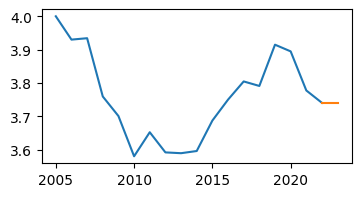

Se predice un cambio en la puntuación de 0.00 en la puntuación local promedio para el eño 2023


In [84]:
categoria = "Seafood"
_ = predict(categoria)


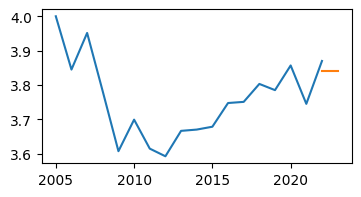

Se predice un cambio en la puntuación de -0.03 en la puntuación local promedio para el eño 2023


In [83]:
categoria = "Bars"
_ = predict(categoria)
